In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np
from dotenv import load_dotenv
from sklearn.pipeline import Pipeline

In [ ]:
data = pd.read_csv("weather_data_khairpur.csv")

In [3]:
print(data.columns[data.columns.duplicated()])

Index([], dtype='str')


In [4]:
data.head()

,date,pm2_5,pm10,aqi,co,no2,ozone,temp,humidity
0,2023-01-01T00:00,35.4,57.7,108,292.0,39.0,22.0,10.3,72
1,2023-01-01T01:00,35.4,58.2,108,298.0,37.9,21.0,9.8,75
2,2023-01-01T02:00,36.0,59.5,107,306.0,35.9,20.0,10.0,75
3,2023-01-01T03:00,37.0,61.2,106,312.0,33.9,20.0,9.3,78
4,2023-01-01T04:00,38.0,63.1,106,319.0,31.6,20.0,8.9,77


In [5]:
data.describe()

,pm2_5,pm10,aqi,co,no2,ozone,temp,humidity
count,31776.000000,31776.000000,31776.000000,31776.000000,31776.000000,31776.000000,31776.000000,31776.000000
mean,40.082115,73.194084,110.423370,380.003588,9.530938,90.613167,26.763195,52.969537
std,21.884658,37.853552,32.033359,246.484551,10.525036,36.416689,8.844668,20.420958
min,2.700000,4.600000,48.000000,92.000000,0.000000,0.000000,3.100000,2.000000
25%,25.000000,47.500000,86.000000,205.000000,3.400000,62.000000,20.100000,38.000000
50%,34.300000,66.100000,101.000000,309.000000,6.500000,86.000000,28.300000,54.000000
75%,49.600000,91.000000,135.000000,473.000000,12.100000,118.000000,33.400000,68.000000
max,188.600000,810.300000,238.000000,2096.000000,116.200000,210.000000,49.200000,100.000000


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 31776 entries, 0 to 31775
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      31776 non-null  str    
 1   pm2_5     31776 non-null  float64
 2   pm10      31776 non-null  float64
 3   aqi       31776 non-null  int64  
 4   co        31776 non-null  float64
 5   no2       31776 non-null  float64
 6   ozone     31776 non-null  float64
 7   temp      31776 non-null  float64
 8   humidity  31776 non-null  int64  
dtypes: float64(6), int64(2), str(1)
memory usage: 2.7 MB


In [7]:
data.isnull().sum()

date        0
pm2_5       0
pm10        0
aqi         0
co          0
no2         0
ozone       0
temp        0
humidity    0
dtype: int64

In [8]:
data['pm10'] = data['pm10'].fillna(data['pm10'].mean())
data['aqi'] = data['aqi'].fillna(data['aqi'].mean())
data['co'] = data['co'].fillna(data['co'].mean())
data['no2'] = data['no2'].fillna(data['no2'].mean())
data['ozone'] = data['ozone'].fillna(data['ozone'].mean())
data['pm2_5'] = data['pm2_5'].fillna(data['pm2_5'].mean())

In [9]:
data.dropna()

,date,pm2_5,pm10,aqi,co,no2,ozone,temp,humidity
0,2023-01-01T00:00,35.4,57.7,108,292.0,39.0,22.0,10.3,72
1,2023-01-01T01:00,35.4,58.2,108,298.0,37.9,21.0,9.8,75
2,2023-01-01T02:00,36.0,59.5,107,306.0,35.9,20.0,10.0,75
3,2023-01-01T03:00,37.0,61.2,106,312.0,33.9,20.0,9.3,78
4,2023-01-01T04:00,38.0,63.1,106,319.0,31.6,20.0,8.9,77
...,...,...,...,...,...,...,...,...,...
31771,2026-08-16T19:00,26.1,40.7,88,165.0,5.8,75.0,34.5,52
31772,2026-08-16T20:00,26.5,39.6,88,168.0,7.2,64.0,34.1,51
31773,2026-08-16T21:00,23.3,34.3,87,158.0,6.6,62.0,33.8,52
31774,2026-08-16T22:00,20.7,30.7,87,141.0,5.0,64.0,33.4,55


In [10]:
data.isnull().sum()

date        0
pm2_5       0
pm10        0
aqi         0
co          0
no2         0
ozone       0
temp        0
humidity    0
dtype: int64

In [11]:
data.drop_duplicates()

,date,pm2_5,pm10,aqi,co,no2,ozone,temp,humidity
0,2023-01-01T00:00,35.4,57.7,108,292.0,39.0,22.0,10.3,72
1,2023-01-01T01:00,35.4,58.2,108,298.0,37.9,21.0,9.8,75
2,2023-01-01T02:00,36.0,59.5,107,306.0,35.9,20.0,10.0,75
3,2023-01-01T03:00,37.0,61.2,106,312.0,33.9,20.0,9.3,78
4,2023-01-01T04:00,38.0,63.1,106,319.0,31.6,20.0,8.9,77
...,...,...,...,...,...,...,...,...,...
31771,2026-08-16T19:00,26.1,40.7,88,165.0,5.8,75.0,34.5,52
31772,2026-08-16T20:00,26.5,39.6,88,168.0,7.2,64.0,34.1,51
31773,2026-08-16T21:00,23.3,34.3,87,158.0,6.6,62.0,33.8,52
31774,2026-08-16T22:00,20.7,30.7,87,141.0,5.0,64.0,33.4,55


In [12]:
data = data.dropna()

In [13]:
data.isnull().sum()

date        0
pm2_5       0
pm10        0
aqi         0
co          0
no2         0
ozone       0
temp        0
humidity    0
dtype: int64

In [14]:
data.head(10)

,date,pm2_5,pm10,aqi,co,no2,ozone,temp,humidity
0,2023-01-01T00:00,35.4,57.7,108,292.0,39.0,22.0,10.3,72
1,2023-01-01T01:00,35.4,58.2,108,298.0,37.9,21.0,9.8,75
2,2023-01-01T02:00,36.0,59.5,107,306.0,35.9,20.0,10.0,75
3,2023-01-01T03:00,37.0,61.2,106,312.0,33.9,20.0,9.3,78
4,2023-01-01T04:00,38.0,63.1,106,319.0,31.6,20.0,8.9,77
5,2023-01-01T05:00,37.8,60.8,105,337.0,24.0,29.0,9.6,76
6,2023-01-01T06:00,38.8,62.4,104,349.0,26.4,25.0,9.1,77
7,2023-01-01T07:00,40.7,65.0,104,365.0,29.7,20.0,9.1,76
8,2023-01-01T08:00,44.0,68.9,103,377.0,31.3,20.0,10.0,70
9,2023-01-01T09:00,46.2,71.2,103,371.0,28.1,32.0,13.0,58


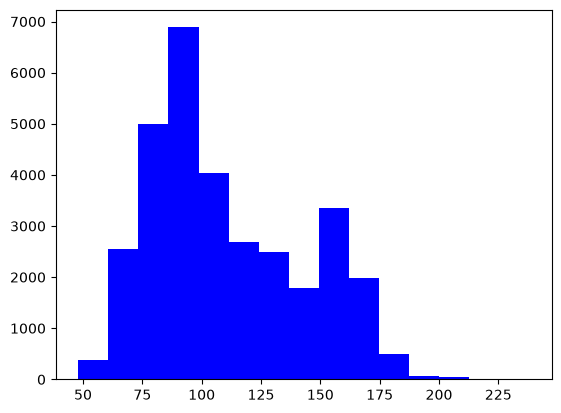

In [15]:
plt.hist(data['aqi'],bins=15,color='blue')
plt.show()

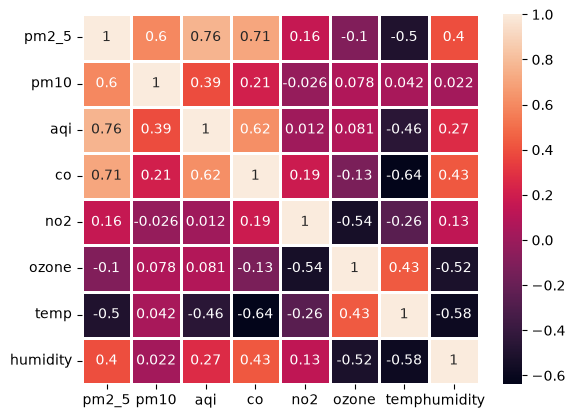

In [16]:
sns.heatmap(data.corr(numeric_only=True),annot=True,linewidths=1)
plt.show()

In [17]:
st = StandardScaler()

In [18]:
cols = ["pm2_5","pm10","co","no2","ozone","temp","humidity"]
data[cols] = st.fit_transform(data[cols])

In [19]:
data.head()

,date,pm2_5,pm10,aqi,co,no2,ozone,temp,humidity
0,2023-01-01T00:00,-0.213948,-0.409323,108,-0.357041,2.799945,-1.884143,-1.861399,0.931923
1,2023-01-01T01:00,-0.213948,-0.396114,108,-0.332698,2.695431,-1.911603,-1.917931,1.078833
2,2023-01-01T02:00,-0.186532,-0.361771,107,-0.300241,2.505405,-1.939064,-1.895318,1.078833
3,2023-01-01T03:00,-0.140837,-0.316860,106,-0.275898,2.315379,-1.939064,-1.974463,1.225744
4,2023-01-01T04:00,-0.095142,-0.266666,106,-0.247498,2.096849,-1.939064,-2.019689,1.176773


In [20]:
X=data[["pm2_5","pm10","co","no2","ozone","temp","humidity"]]
y=data["aqi"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [22]:
model = RandomForestRegressor(n_estimators=100,random_state=42)
model.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [23]:
preds = model.predict(X_test)

In [24]:
mse = mean_squared_error(y_test,preds)
mae = mean_absolute_error(y_test,preds)
rme = np.sqrt(mean_squared_error(y_test,preds))
r2 = r2_score(y_test,preds)

In [25]:
print(f'MAE{mae : .2f}')
print(f"RMSE{rme : .2f}")
print(f"R2{r2 : .2f}")

MAE 10.90
RMSE 14.90
R2 0.78


In [26]:
from sklearn.tree import DecisionTreeRegressor

In [27]:
dt = DecisionTreeRegressor(max_depth=5,min_samples_split=10)

In [28]:
dt.fit(X_train,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes 

In [29]:
pre = dt.predict(X_test)

In [30]:
mse_t = mean_squared_error(y_test,pre)
mae_t = mean_absolute_error(y_test,pre)
rme_t = np.sqrt(mean_squared_error(y_test,pre))
r2_t = r2_score(y_test,pre)

In [31]:
print(f'MAE{mae_t : .2f}')
print(f"RMSE{rme_t : .2f}")
print(f"R2{r2_t : .2f}")

MAE 13.98
RMSE 18.27
R2 0.68


In [32]:
from sklearn.ensemble import GradientBoostingRegressor

In [33]:
gbr = GradientBoostingRegressor(n_estimators=100,validation_fraction=0.2,n_iter_no_change=10)

In [34]:
gbr.fit(X_train,y_train)

,"validation_fraction validation_fraction: float, default=0.1The proportion of training data to set aside as validation set forearly stopping. Values must be in the range `(0.0, 1.0)`.Only used if ``n_iter_no_change`` is set to an integer... versionadded:: 0.20",0.2
,"n_iter_no_change n_iter_no_change: int, default=None``n_iter_no_change`` is used to decide if early stopping will be usedto terminate training when validation score is not improving. Bydefault it is set to None to disable early stopping. If set to anumber, it will set aside ``validation_fraction`` size of the trainingdata as validation and terminate training when validation score is notimproving in all of the previous ``n_iter_no_change`` numbers ofiterations.Values must be in the range `[1, inf)`.See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_early_stopping.py`... versionadded:: 0.20",10
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the inpu

In [35]:
modelgbr = gbr.predict(X_test)

In [36]:
mse_g = mean_squared_error(y_test,modelgbr)
mae_g = mean_absolute_error(y_test,modelgbr)
rme_g = np.sqrt(mean_squared_error(y_test,modelgbr))
r2_g = r2_score(y_test,modelgbr)

In [37]:
print(f'MAE{mae_g : .2f}')
print(f"RMSE{rme_g : .2f}")
print(f"R2{r2_g : .2f}")

MAE 12.81
RMSE 16.85
R2 0.72


In [ ]:
from xgboost import XGBRegressor
print("XGBoost imported successfully")

In [ ]:
xbr = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5)
print("XGBRegressor initialized")

In [ ]:
load_dotenv()

feature_columns = ["pm2_5", "pm10", "co", "no2", "ozone", "temp", "humidity"]
data_file = os.getenv("DATA_FILE", "weather_data_khairpur.csv")
model_path = os.getenv("MODEL_PATH", "aqi_pipeline.pkl")
training_data = pd.read_csv(data_file).dropna(subset=feature_columns + ["aqi"])
X = training_data[feature_columns].astype(np.float32)
y = training_data["aqi"].astype(np.float32)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", XGBRegressor(
        n_estimators=40,
        max_depth=5,
        learning_rate=0.08,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=4,
        tree_method="hist",
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    )),
])
pipeline.fit(X, y)
joblib.dump(pipeline, model_path, compress=3)
print(f"Saved pipeline to {model_path} ({os.path.getsize(model_path) / 1e6:.2f} MB)")